In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [4]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [6]:
force_matrix, cell_map = phonon_force_matrix("$bn22bc_dir/phonon");
phonon_bands_bn22bc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn22bc_buckled_dir/phonon");
phonon_bands_bn22bc_buckled = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn22nc_dir/phonon");
phonon_bands_bn22nc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn33nc_dir/phonon");
phonon_bands_bn33nc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn22bc_dir/phonon");
phonon_bands_bn22bc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn22bc_buckled_dir/phonon");
phonon_bands_bn22bc_buckled = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn33bc_dir/phonon");
phonon_bands_bn33bc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn33bc_buckled_dir/phonon");
phonon_bands_bn33bc_buckled = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn44bc_dir/phonon");
phonon_bands_bn44bc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn44bc_buckled_dir/phonon");
phonon_bands_bn44bc_buckled = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);
force_matrix, cell_map = phonon_force_matrix("$bn44nc_dir/phonon");
phonon_bands_bn44nc = phonon_dispersion(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

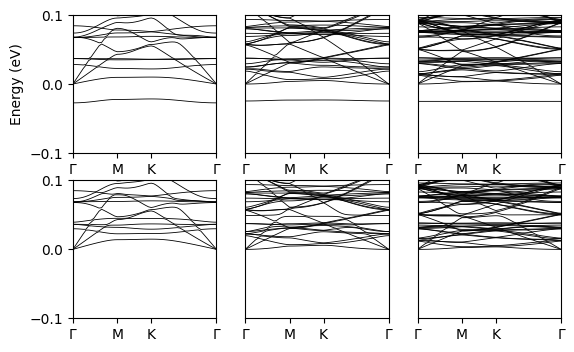

In [45]:
cm = 1/2.54
figure(figsize=(16*cm, 10*cm))
linewidth=0.6
color="black"
subplot(2, 3, 1)
plot(phonon_bands_bn22bc[:, 1:15], linewidth=linewidth, color=color)
label_plots()
ylabel("Energy (eV)")
#title("No Buckling")
yticks([-0.1, 0, 0.1])
ylim(-0.1, 0.1)

subplot(2, 3, 4)
plot(phonon_bands_bn22bc_buckled[:, 1:15], linewidth=linewidth, color=color)
label_plots()
yticks([-0.1, 0, 0.1])
#title("Buckling")
ylim(-0.1, 0.1)


subplot(2, 3, 2)
plot(phonon_bands_bn33bc[:, 1:35], linewidth=linewidth, color=color)
label_plots()
#ylabel("Energy (eV)")
ylim(-0.1, 0.1)

yticks(Float64[])


subplot(2, 3, 5)
plot(phonon_bands_bn33bc_buckled[:, 1:35], linewidth=linewidth, color=color)
label_plots()
#title("Buckling")
ylim(-0.1, 0.1)
yticks(Float64[])


subplot(2, 3, 3)
plot(phonon_bands_bn44bc[:, 1:60], linewidth=linewidth, color=color)
label_plots()
#ylabel("Energy (eV)")
ylim(-0.1, 0.1)
yticks(Float64[])


subplot(2, 3, 6)
plot(phonon_bands_bn44bc_buckled[:, 1:60], linewidth=linewidth, color=color)
label_plots()
yticks(Float64[])
ylim(-0.1, 0.1)

#title("Buckling")
savefig("Buckling-Phonons.pdf")